## Sources/Bibliography:

### **Theodoridis et al.**  
**Προπαρασκευή Δεδομένων (slideshow).** 2024.  
[http://gunet2.cs.unipi.gr/modules/document/file.php/TMD104/Lectures/2-DataPrep.pdf](http://gunet2.cs.unipi.gr/modules/document/file.php/TMD104/Lectures/2-DataPrep.pdf)

### **Aurélien Géron**  
**Hands-On Machine Learning with Scikit-Learn and TensorFlow.** 2022.  
[https://www.oreilly.com/library/view/hands-on-machine-learning/9781098125967/](https://www.oreilly.com/library/view/hands-on-machine-learning/9781098125967/)

---

### **An Introduction to Virtual Environments in Python**  
[https://medium.com/@dakota.lillie/an-introduction-to-virtual-environments-in-python-ce16cda92853](https://medium.com/@dakota.lillie/an-introduction-to-virtual-environments-in-python-ce16cda92853)  

```sh
pip install numpy pandas seaborn matplotlib geopandas contextily
```

### **ALTERNATIVE**
[Setting up Miniconda on Ubuntu]([https://medium.com/featurepreneur/setting-up-miniconda-on-ubuntu-4bf6bece6f9b])

```sh
conda install -c conda-forge numpy pandas seaborn matplotlib geopandas contextily
```

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import missingno as msno
import numpy as np
import pandas as pd
import contextily as ctx
import seaborn as sns
import sklearn
import geopandas as gpd
from matplotlib import pyplot as plt

### Dataset: [California Housing Prices](https://www.kaggle.com/camnugent/california-housing-prices)

In [2]:
data = pd.read_csv("data/housing.csv")

### **Getting Familiar with the Data (i.e., Pandas 101)**  

Before diving into any data analysis or Machine Learning project, it's **crucial to explore and understand the dataset**. This involves using **Pandas**, a powerful Python library for data manipulation and analysis. The process typically includes:  

1. **Loading the Data** 📂  
2. **Inspecting the Structure** 🔍  
3. **Summarizing the Data** 📊  
4. **Handling Missing Data** 🚨  
5. **Exploring Relationships** 📈  

### **Why This Matters?**  
By thoroughly exploring the dataset, you **gain intuition** about its structure, spot inconsistencies, and prepare it for **feature engineering, visualization, and modeling**. 🚀  

Would you like an example walkthrough with a real dataset? 😊

## 🏡 California Housing Dataset: Feature Descriptions  

1. **🌍 Longitude**: Measures how far **west** a house is. 
2. **🌎 Latitude**: Measures how far **north** a house is.
3. **🏗 Housing Median Age**: Median age of a house within a block.
4. **🛏 Total Rooms**: Total number of **rooms** within a block.  
5. **🛌 Total Bedrooms**: Total number of **bedrooms** within a block.  
6. **👨‍👩‍👧 Population**: Total number of **people residing** within a block.  
7. **🏠 Households**: Total number of **households** within a block.  
8. **💰 Median Income**: Median **income** for households within a block. (Measured in **10K$**.)  
9. **🏡 Median House Value**: Median **house value** for households within a block. (Measured in **$**)  
10. **🌊 Ocean Proximity**: Location of the house relative to the ocean/sea.  


## Types of Statistics

### 1. **Descriptive Statistics**  
**Description:**  
Summarizes and organizes data to describe its main features. This often involves measures like **mean**, **median**, **mode**, **range**, **variance**, and **standard deviation**. The goal is to present data in a clear and concise way through **tables**, **charts**, or **graphs**.

**Sample Use Cases:**  
- Calculating the **average test scores** of students in a class.
- Creating **histograms** to display the **distribution of customer ages** in a store.

---

### 2. **Inferential Statistics**  
**Description:**  
Uses sample data to make **generalizations** or **predictions** about a larger population. It involves techniques like **hypothesis testing**, **confidence intervals**, and **regression analysis** to draw conclusions with a degree of certainty.

**Sample Use Cases:**  
- Estimating the **average income** of a country's population based on a survey sample.
- **Predicting election outcomes** by analyzing polling data.

---

### 3. **Predictive Statistics**  
**Description:**  
Focuses on using **historical data** and statistical models to **predict future outcomes** or trends. Techniques include **regression models**, **time series analysis**, and **machine learning algorithms**.

**Sample Use Cases:**  
- **Forecasting sales** for the next quarter based on past performance.
- **Predicting customer churn** in a subscription-based business.

---

### 4. **Prescriptive Statistics**  
**Description:**  
Provides **recommendations** for decision-making based on data analysis and optimization models. It combines statistical methods with **operations research** to suggest actions that can lead to desired outcomes.

**Sample Use Cases:**  
- **Optimizing supply chain logistics** to minimize costs.
- **Recommending personalized products** to customers in e-commerce platforms.

---

## Key Differences:

| Type                     | Focus                                    | Techniques Involved                             | Common Use Cases                                   |
|--------------------------|------------------------------------------|-------------------------------------------------|---------------------------------------------------|
| **Descriptive**           | Summarizing and presenting data         | Mean, Median, Mode, Range, Standard Deviation   | Average test scores, customer age distribution     |
| **Inferential**           | Making predictions about a population    | Hypothesis Testing, Confidence Intervals, Regression Analysis | Estimating average income, predicting election outcomes |
| **Predictive**            | Forecasting future trends or behaviors   | Regression Models, Time Series, Machine Learning | Sales forecasting, customer churn prediction      |
| **Prescriptive**          | Recommending actions based on data       | Optimization Models, Decision Analysis          | Supply chain optimization, personalized product recommendations |



In [ ]:
data

In [ ]:
# Size and Structure of Data
*data.shape, data.columns

In [3]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
data.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


## Baseline Statistics

In [5]:
# data[['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']].describe()
data.describe().round(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


In [6]:
data.ocean_proximity.describe()

count         20640
unique            5
top       <1H OCEAN
freq           9136
Name: ocean_proximity, dtype: object

In [8]:
# More Quantiles
data.select_dtypes(["number"]).quantile([0.1, 0.3, 0.5, 0.7])

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0.1,-122.29,33.63,13.0,941.0,198.0,510.0,184.0,1.9038,82300.0
0.3,-121.37,34.00,20.0,1578.0,322.0,859.0,305.0,2.7401,134000.0
0.5,-118.49,34.26,29.0,2127.0,435.0,1166.0,409.0,3.5348,179700.0
0.7,-118.13,37.48,36.0,2876.0,591.0,1580.0,553.0,4.4375,241930.0


## Visualizations
- Missing Values per Feature
- Feature Distributions

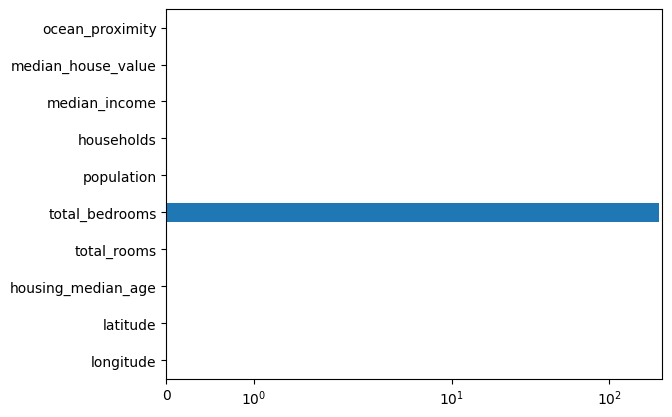

In [9]:
fig, ax = plt.subplots(1, 1)
data.isna().sum().plot.barh(ax=ax)

ax.set_xscale("symlog")

plt.show()

### Alternative (more 'elegant') method

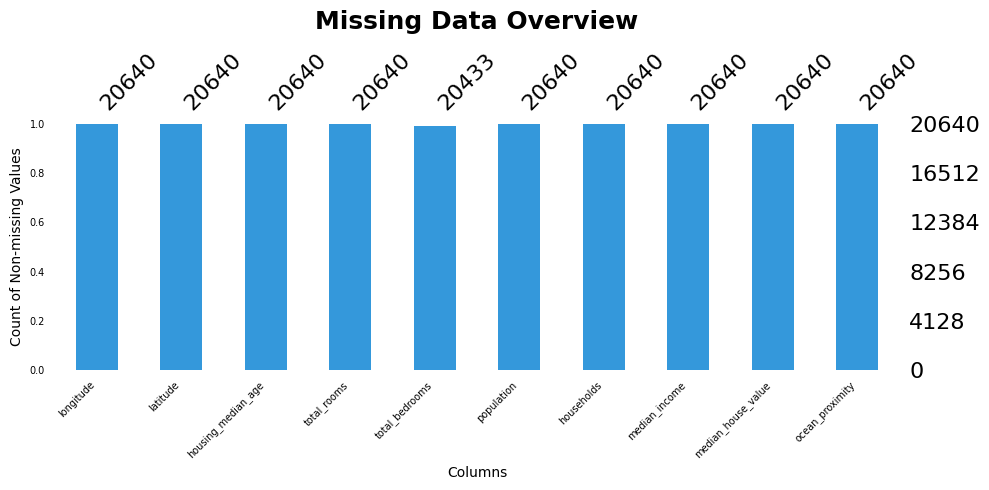

In [10]:
# Create figure and axis with a specified size
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Generate the missing data bar plot with custom color
msno.bar(data, ax=ax, color="#3498db")

# Until here we achieve the same functionality
# ================================ #

# Enhance plot aesthetics
ax.set_title("Missing Data Overview", fontsize=18, fontweight="bold", pad=15)
ax.set_xlabel("Columns", fontsize=10)
ax.set_ylabel("Count of Non-missing Values", fontsize=10)

# Reduce font size for bar labels (values on top of bars) and side index labels
ax.tick_params(axis="both", which="major", labelsize=7)  # Shrinks x and y ticks

# Remove top and right spines for a cleaner look
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Adjust layout to prevent clipping of labels
plt.tight_layout()
plt.show()

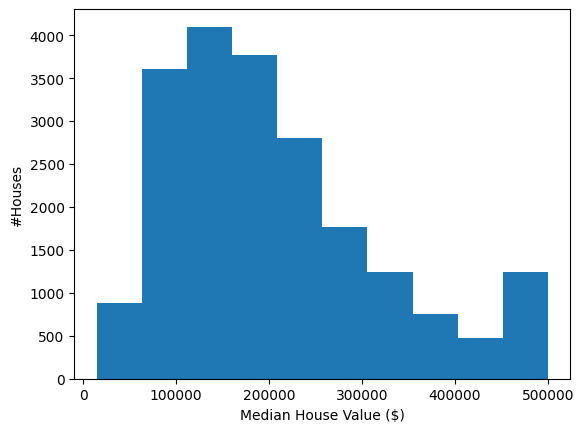

In [14]:
fig, ax = plt.subplots(1, 1)

data["median_house_value"].plot.hist(bins=10, alpha=1, ax=ax)
ax.set_xlabel("Median House Value ($)")
ax.set_ylabel("#Houses")

plt.show()

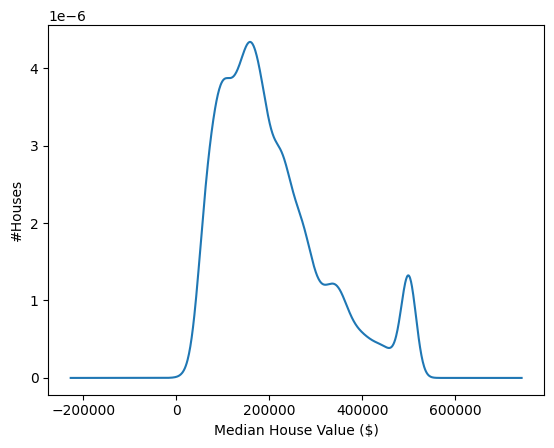

In [15]:
fig, ax = plt.subplots(1, 1)

data.median_house_value.plot.density(ax=ax)
ax.set_xlabel("Median House Value ($)")
ax.set_ylabel("#Houses")

plt.show()

Why not combine those two figures into a single one?

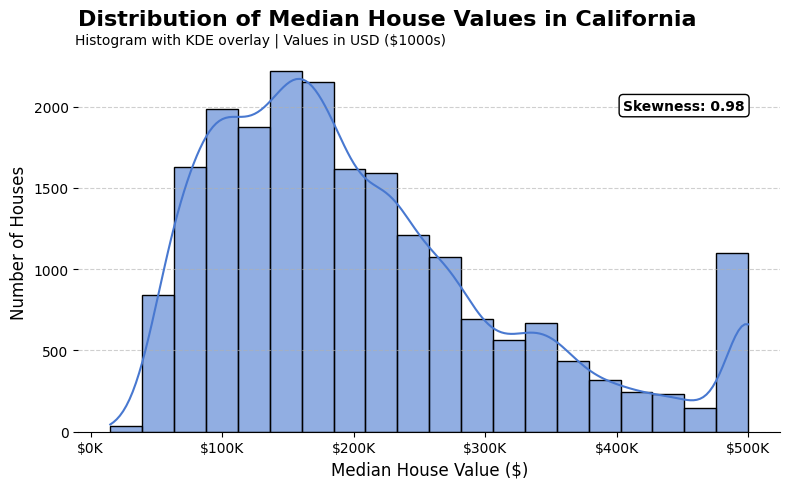

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# Custom color for better visibility
color = sns.color_palette("muted")[0]

sns.histplot(
    data=data,
    x="median_house_value",
    bins=20,
    kde=True,
    ax=ax,
    color=color,
    alpha=0.6,
)

# Formatting large numbers for x-axis
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

# Set labels with improved clarity
ax.set_xlabel("Median House Value ($)", fontsize=12)
ax.set_ylabel("Number of Houses", fontsize=12)

# Adding skewness annotation
skewness = data["median_house_value"].skew()
ax.text(
    0.95,
    0.85,
    f"Skewness: {skewness:.2f}",
    transform=ax.transAxes,
    ha="right",
    color="black",
    weight="bold",
    fontsize=10,
    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"),
)

# Add title and subtitle
ax.set_title(
    "Distribution of Median House Values in California",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=20,
)
plt.figtext(
    0.1,
    0.9,
    "Histogram with KDE overlay | Values in USD ($1000s)",
    fontsize=10,
    ha="left",
)

# Grid and despine for a cleaner look
ax.grid(axis="y", linestyle="--", alpha=0.6)
sns.despine(left=True)

plt.tight_layout()
plt.show()

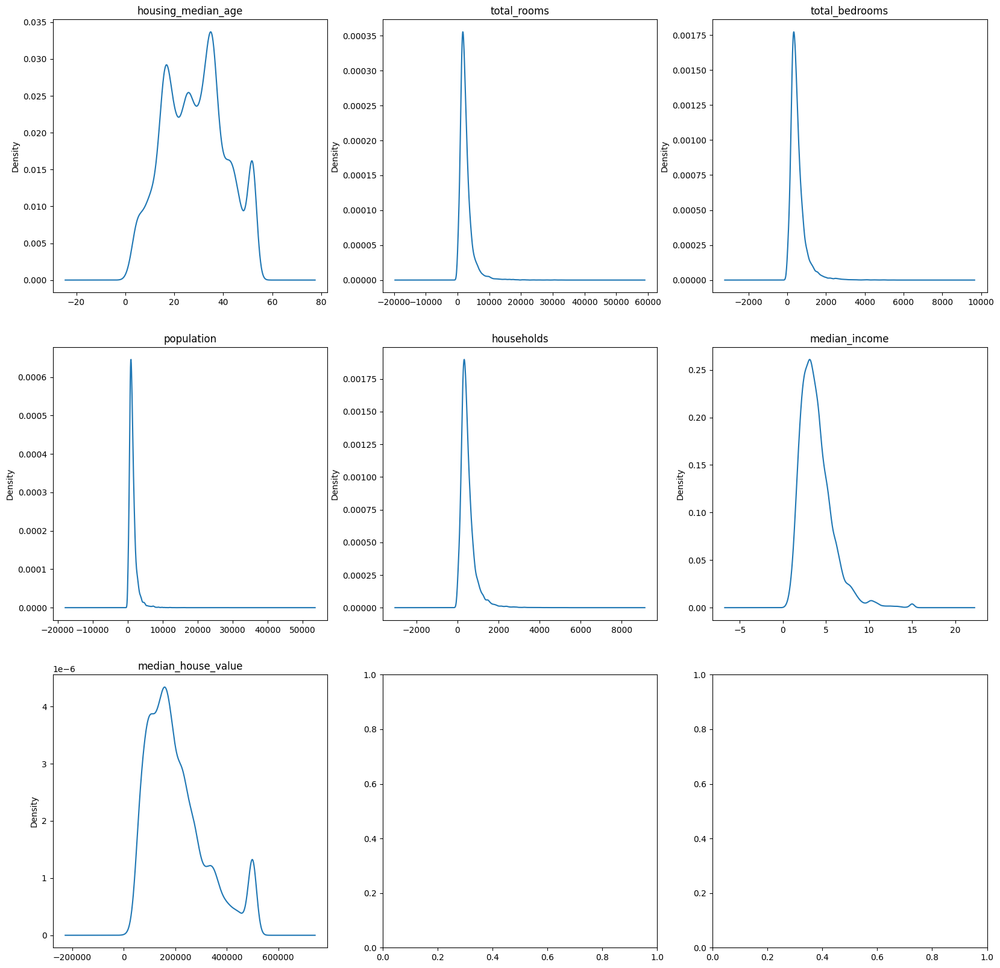

In [17]:
# "Classic" method
numeric_feats = [
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "median_house_value",
]

fig, ax = plt.subplots(3, 3, figsize=(20, 20))
i, j = 0, 0

for idx, feat in enumerate(numeric_feats):
    data[feat].plot.density(ax=ax[i, j])
    ax[i, j].set_title(feat)

    if (idx + 1) % 3 == 0:
        i += 1
        j = 0
    else:
        j += 1

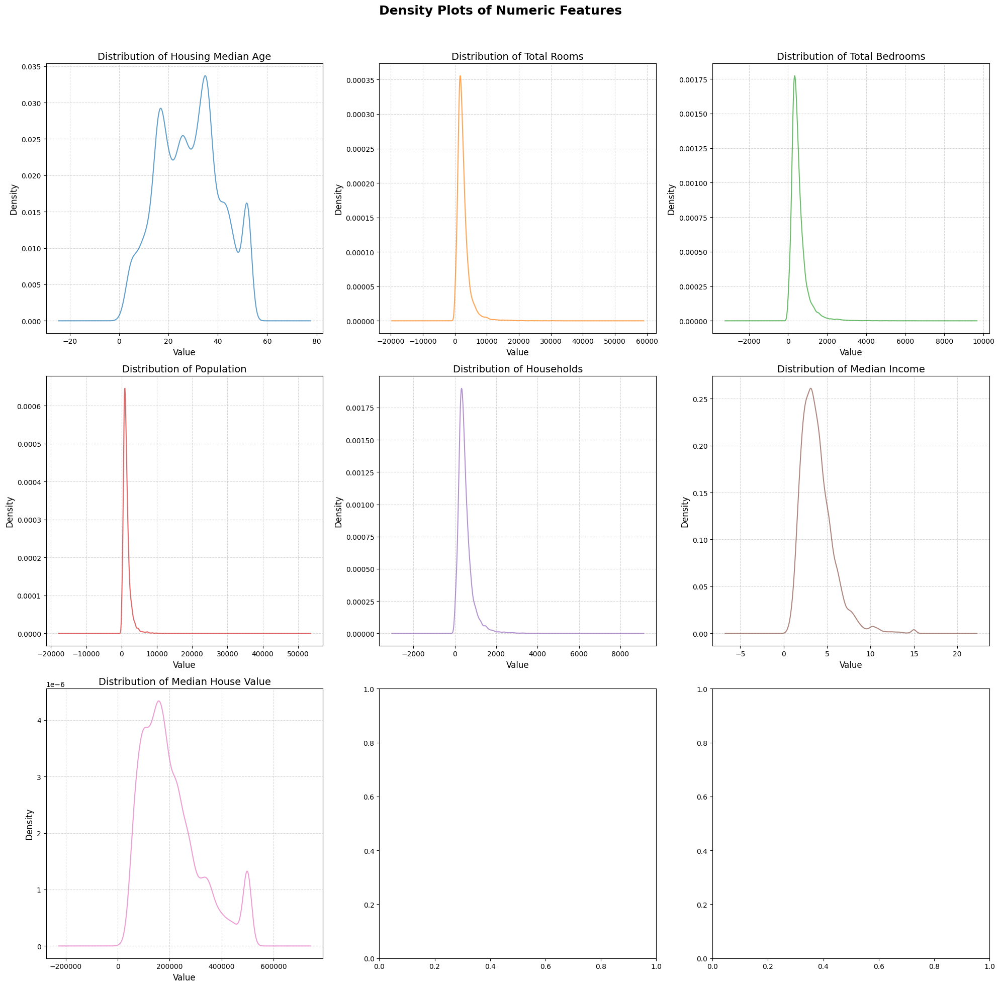

In [18]:
numeric_feats = [
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "median_house_value",
]

fig, ax = plt.subplots(3, 3, figsize=(20, 20))

# Loop over numeric features to plot density curves
for idx, (ax_i, feat) in enumerate(zip(ax.flatten(), numeric_feats)):
    data[feat].plot.density(
        ax=ax_i, alpha=0.7, color=f"C{idx}"
    )  # Different color for each plot
    ax_i.set_title(f"Distribution of {feat.replace('_', ' ').title()}", fontsize=14)
    ax_i.set_xlabel("Value", fontsize=12)
    ax_i.set_ylabel("Density", fontsize=12)
    ax_i.grid(True, linestyle="--", alpha=0.5)

# Adjust spacing and add a figure title
fig.suptitle("Density Plots of Numeric Features", fontsize=18, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.96))  # Ensure the title doesn't overlap with subplots
plt.show()

### Categorical Features

Those visualizations can help with part-to-whole relationships

In [19]:
data.ocean_proximity.value_counts(sort=False)

ocean_proximity
NEAR BAY      2290
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
ISLAND           5
Name: count, dtype: int64

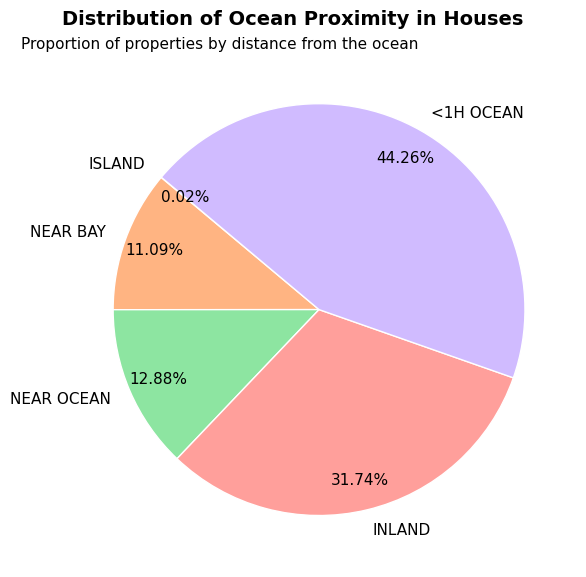

In [20]:
# Compute proportions
out = data["ocean_proximity"].value_counts(normalize=True).sort_values()

# Create figure
fig, ax = plt.subplots(figsize=(6, 6))

# Apply Seaborn style and color palette
colors = sns.color_palette("pastel", len(out))

# Create pie chart
ax.pie(
    out,
    labels=out.index,
    autopct="%1.2f%%",
    startangle=140,
    colors=colors,
    wedgeprops={"edgecolor": "white"},
    pctdistance=0.85,
    textprops={"fontsize": 11},
)

# Add title and subtitle
ax.set_title(
    "Distribution of Ocean Proximity in Houses",
    fontsize=14,
    fontweight="bold",
    loc="left",
    pad=20,
)
plt.figtext(
    0.05,
    0.9,
    "Proportion of properties by distance from the ocean",
    ha="left",
    fontsize=11,
)

plt.tight_layout()
plt.show()

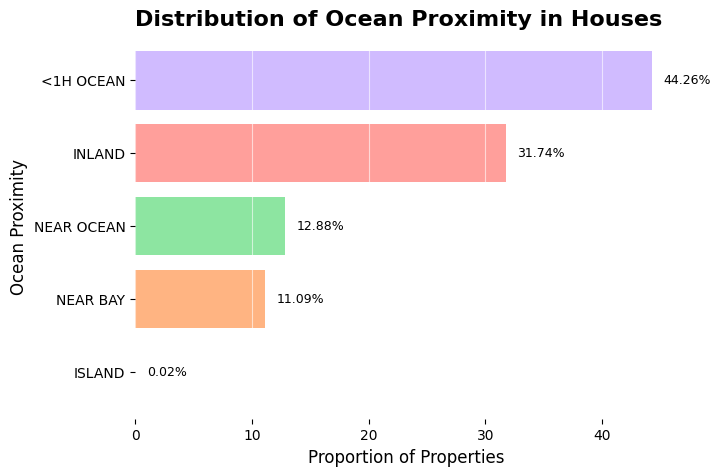

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))

# Sort categories and plot as bar chart
bars = ax.barh(out.index, out.values * 100, color=colors)

# Add labels
ax.set_xlabel("Proportion of Properties", fontsize=12)
ax.set_ylabel("Ocean Proximity", fontsize=12)
ax.set_title(
    "Distribution of Ocean Proximity in Houses",
    fontsize=16,
    fontweight="bold",
    loc="left",
)

# Add annotations at the end of each bar
for bar in bars:
    ax.text(
        bar.get_width() + 1,  # Position slightly outside the bar
        bar.get_y() + bar.get_height() / 2,  # Center text on the bar
        f"{bar.get_width():.2f}%",  # Format as percentage
        va="center",
        fontsize=9,
    )

plt.grid(axis="x", alpha=0.6, color="white")
sns.despine(left=True, bottom=True)
plt.show()

### **Comparison: Pie Chart vs. Bar Chart**

| **Principle**               | **Pie Chart** ⭐ | **Bar Chart** ✅ |
|-----------------------------|-----------------|-----------------|
| **Clarity & Simplicity**     | Harder to compare slices, especially for small differences. | Easier to compare lengths of bars. |
| **Correct Chart Type**       | Works well for part-to-whole but struggles with many categories. | Works well for categorical distributions. |
| **Effective Use of Color**   | Uses colors to differentiate slices but may become cluttered. | Uses colors effectively, especially with horizontal bars. |
| **Providing Context**        | Labels are inside the slices, making them harder to read. | Labels and values are clearly displayed. |


### Geospatial Visuals

### **TL;DR**  
- ✅ **EPSG 4326** is used for **accurate geospatial positioning** and analysis.  
- ⚠️ **EPSG 3857** is ideal for **web maps** but comes with **projection distortions**.

--- 

### 📍 **EPSG 4326 (WGS 84)** 🌍  
- 📌 **Type:** Geographic Coordinate System  
- 📡 **Projection:** None (latitude/longitude grid)  
- 📏 **Units:** Degrees (Latitude: -90° to 90°, Longitude: -180° to 180°) 
- 🎯 **Use Cases:**  
  - 📡 **GPS Systems**  
  - 🛰 **Geospatial Databases**  
  - 🌐 **Global positioning and analysis**  
- 🖼 **Shape of Earth:** 🌍 **Ellipsoid/Geoid**  
- 🔍 **Distortion:** No distortion (accurate for geodetic calculations) 
- 🔄 **Conversion:** Can be projected into any coordinate system
- ✅ **Measurement Accuracy:**  Great-circle distances -accurate, perfect for geodetic analysis
- 📍 **Map Extent:** 🌎 **Global coverage** (no exclusions)  

---

### 🗺 **EPSG 3857 (Web Mercator)**  
- 📌 **Type:** Projected Coordinate System  
- 📡 **Projection:** 🔄 **Spherical Mercator Projection**  
- 📏 **Units:** Meters (values can exceed ±20 million)   
- 🎯 **Use Cases:**  
  - 🗺 **Web Mapping**  
  - 🌍 **Tile-based Map Services**  
  - 📲 **Google Maps, OpenStreetMap, Mapbox**  
- 🖼 **Shape of Earth:** ⚠️ **Assumed as a sphere**  
- 🔍 **Distortion:** Severe distortion near poles (Greenland/Antarctica appear large)  
- 🔄 **Conversion:** Requires transformation (e.g., via PROJ, GDAL) to convert to geodetic CRS
- ✅ **Measurement Accuracy:** Linear distances - distorted, especially at higher latitudes  
- 📍 **Map Extent:** 📉 **Excludes polar regions** (latitudes: ~85.06°N/S)


/Users/tonytziorvas/Documents/1.Personal/Lectures/Data-Analytics/.venv/lib/python3.11/site-packages/contextily/tile.py:645: UserWarning: The inferred zoom level of 23 is not valid for the current tile provider (valid zooms: 0 - 20).
  warnings.warn(msg)


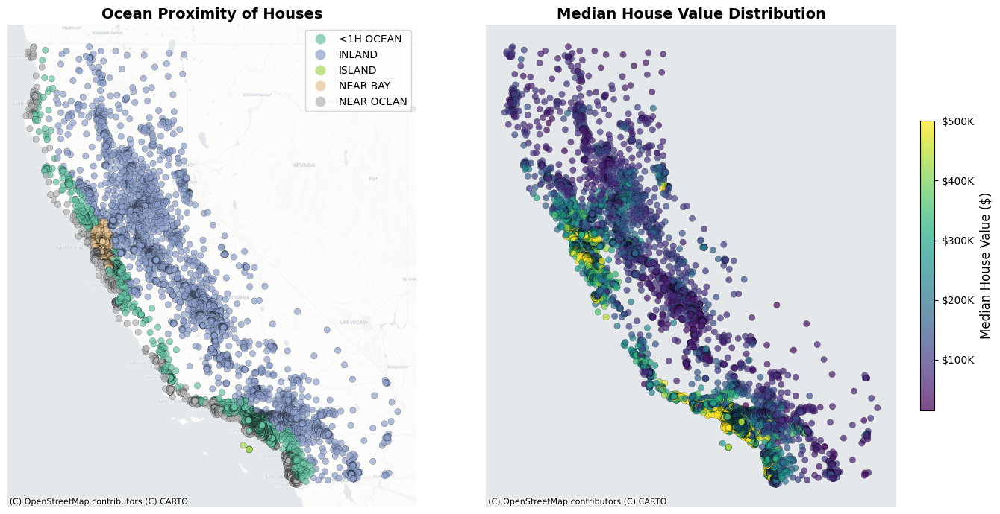

In [22]:
# Convert to GeoDataFrame with the correct projection
gdf = gpd.GeoDataFrame(
    data,
    crs=4326,
    geometry=gpd.points_from_xy(data["longitude"], data["latitude"]),
)

fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# PLOT #1 - Ocean Proximity
gdf.to_crs(epsg=3857).plot(
    ax=ax[0],
    column="ocean_proximity",
    cmap="Set2",  # Categorical colormap
    legend=True,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.2,
)
ctx.add_basemap(ax[0], source=ctx.providers.CartoDB.Positron, alpha=0.6)
ax[0].set_title("Ocean Proximity of Houses", fontsize=14, fontweight="bold")
ax[0].set_axis_off()

# PLOT #2 - Median House Value
gdf.plot(
    ax=ax[1],
    column="median_house_value",
    cmap="viridis",
    legend=False,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.2,
)
ctx.add_basemap(ax[1], source=ctx.providers.CartoDB.Positron, alpha=0.6)
ax[1].set_title("Median House Value Distribution", fontsize=14, fontweight="bold")
ax[1].set_axis_off()

# Improve legend formatting
cbar = ax[1].get_figure().colorbar(ax[1].collections[0], ax=ax[1], fraction=0.03)
cbar.set_label("Median House Value ($)", fontsize=12)
cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

plt.tight_layout()
# plt.savefig("data_improved.png", dpi=300)
plt.show()

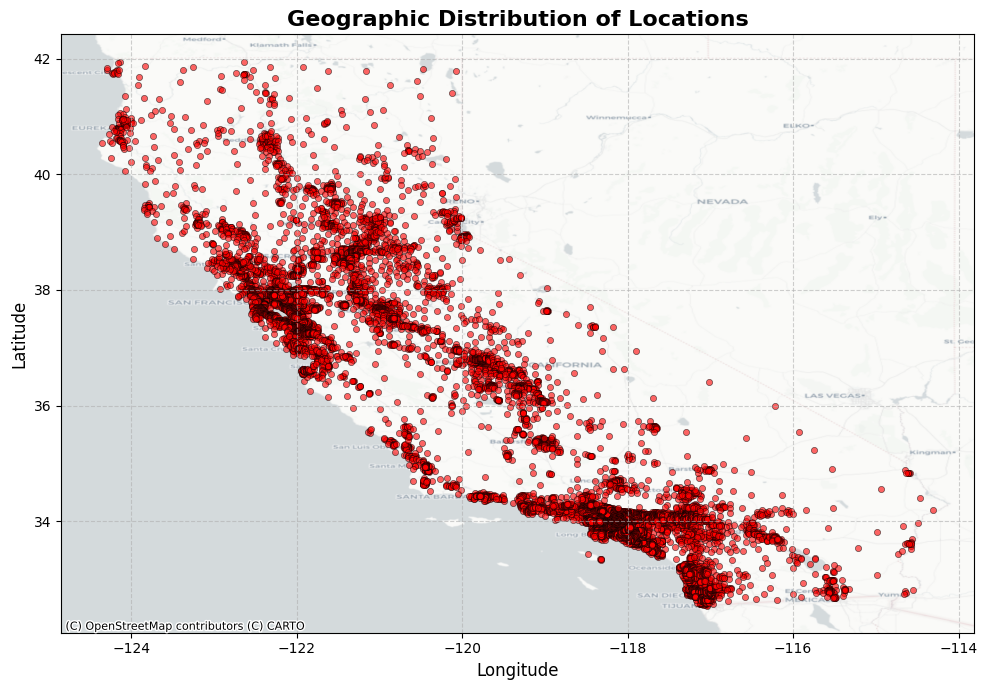

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Scatter plot with transparency
data.plot.scatter(
    x="longitude",
    y="latitude",
    ax=ax,
    alpha=0.6,
    color="red",  # Customize the point color
    edgecolor="black",
    linewidth=0.5,
)

# Adding basemap
ctx.add_basemap(ax=ax, source=ctx.providers.CartoDB.Positron, crs=4326)

# Adding title and axis labels
ax.set_title("Geographic Distribution of Locations", fontsize=16, fontweight="bold")
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

# Adding grid for better spatial alignment
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [24]:
# Assuming you have a GeoDataFrame 'gdf' for city boundaries
gdf.explore(column="median_house_value", cmap="viridis", legend=True)

### **TL;DR - Which One to Use?**
- Use plot() if you need static maps for reporting, publications, or when you have smaller datasets.
- Use explore() if you need an interactive map for quick exploration, especially with larger datasets or when you need to allow users to interact with the map for further details.

---

| Feature/Aspect          | `plot()` (Static Plot)                               | `explore()` (Interactive Plot)                      |
|-------------------------|----------------------------------------------------|----------------------------------------------------|
| **Interactivity**        | No                                                 | Yes (zoom, pan, hover, click)                      |
| **Customization**        | Basic (color, title, basemap)                      | More advanced (color coding, popups, hover details) |
| **Rendering Library**    | `matplotlib` with `contextily` for basemap         | `folium` (rendered in a web browser)               |
| **Performance**          | Fast and responsive (good for small to medium datasets) | Can be slower with large datasets                  |
| **Exporting**            | Easy to export as `.png`, `.pdf`, etc.             | Not directly exportable as an image                |

## Correlation/Covariance

In [25]:
data.select_dtypes(include=["number"]).corr(method="pearson")

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


A few things to consider when using and interpreting correlation:
- What are you trying to prove (or not) ?
- What assumptions does each method make ?
- What are the limitations of each method ?

Pearson: Assumes a linear relationship and that data is normally distributed.\
Spearman's Rank: Non-parametric but assumes a monotonic relationship\
Kendall's Tau: Non-parametric and makes no assumptions about the data distribution.

Further Reading: [Choosing the Right Correlation: Pearson vs. Spearman vs. Kendall’s Tau](https://ishanjainoffical.medium.com/choosing-the-right-correlation-pearson-vs-spearman-vs-kendalls-tau-02dc7d7dd01d)

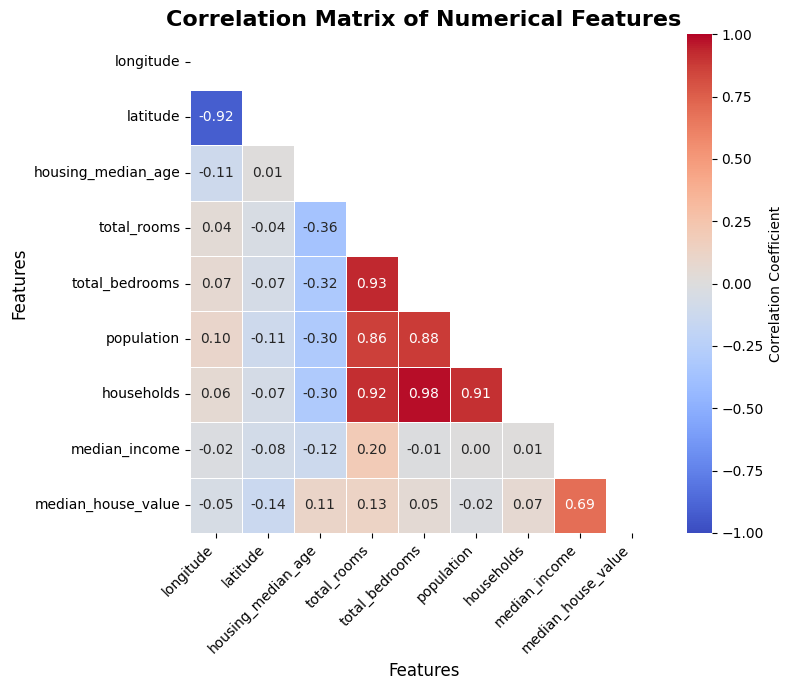

In [26]:
# Calculate the correlation matrix
corr = data.select_dtypes(include=["number"]).corr(method="pearson").round(2)

# Create the mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Create the heatmap with the mask
plt.figure(figsize=(8, 7))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,  # Ensure that color scaling is consistent
    cbar_kws={"label": "Correlation Coefficient"},
    annot_kws={"size": 10},  # Adjust annotation size
    mask=mask,  # Apply the mask to hide the upper triangle
)

# Title and labels for context
plt.title("Correlation Matrix of Numerical Features", fontsize=16, fontweight="bold")
plt.xlabel("Features", fontsize=12)
plt.ylabel("Features", fontsize=12)

# Rotate the axis labels for better readability
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0, ha="right")

plt.tight_layout()
plt.show()

In [28]:
data.select_dtypes(include=["number"]).cov()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,4.014139,-3.957054,-2.728244,1.948037e+02,5.876851e+01,2.263778e+02,4.236807e+01,-0.057765,-1.062743e+04
latitude,-3.957054,4.562293,0.300346,-1.682178e+02,-6.029962e+01,-2.631378e+02,-5.801024e+01,-0.323860,-3.553256e+04
housing_median_age,-2.728244,0.300346,158.396260,-9.919120e+03,-1.700313e+03,-4.222271e+03,-1.457581e+03,-2.846140,1.533988e+05
total_rooms,194.803750,-168.217847,-9919.120060,4.759445e+06,8.567306e+05,2.117613e+06,7.661046e+05,820.852410,3.377289e+07
total_bedrooms,58.768508,-60.299623,-1700.312817,8.567306e+05,1.775654e+05,4.191391e+05,1.578295e+05,-6.180851,2.416878e+06
population,226.377839,-263.137814,-4222.270582,2.117613e+06,4.191391e+05,1.282470e+06,3.928036e+05,10.400979,-3.221249e+06
households,42.368072,-58.010245,-1457.581290,7.661046e+05,1.578295e+05,3.928036e+05,1.461760e+05,9.466667,2.904924e+06
median_income,-0.057765,-0.323860,-2.846140,8.208524e+02,-6.180851e+00,1.040098e+01,9.466667e+00,3.609323,1.508475e+05
median_house_value,-10627.425205,-35532.559074,153398.801329,3.377289e+07,2.416878e+06,-3.221249e+06,2.904924e+06,150847.482793,1.331615e+10


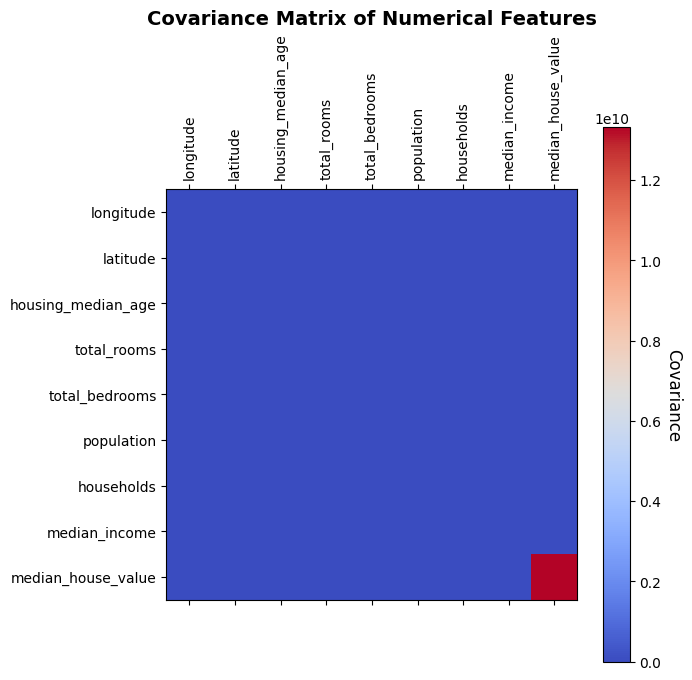

In [29]:
# Compute the covariance matrix
cov_matrix = data.select_dtypes(["number"]).cov()

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
sm = ax.matshow(cov_matrix, cmap="coolwarm")

# Adjust ticks and labels
plt.xticks(
    range(cov_matrix.shape[1]),
    cov_matrix.columns,
    rotation=90,
    ha="center",
    fontsize=10,
)
plt.yticks(range(cov_matrix.shape[0]), cov_matrix.columns, fontsize=10)

# Add colorbar with label
cbar = plt.colorbar(sm)
cbar.set_label("Covariance", rotation=270, labelpad=15, fontsize=12)

# Add title and adjust layout
ax.set_title("Covariance Matrix of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

# Optionally save the figure
# plt.savefig("figures/covmap.png", dpi=300)
plt.show()

### 🔍 The Plots Display Seemingly "Conflicted" Conclusions (Why?)x

#### 📊 **Covariance** vs. **Correlation**: Key Differences

- **Covariance** is an indicator of the extent to which two random variables are dependent on each other. A **higher value** denotes a **stronger dependency**.  
- **Correlation**, on the other hand, is a statistical measure that indicates **how strongly** two variables are related.

---

#### 📈 **Covariance vs. Correlation**: Differences to Know  

- **Covariance**:  
  - Reveals how two variables **change together**.  
  - Indicates the **direction** of the linear relationship between the variables.  
  - **Not standardized** – values are not scaled, which can make interpretation difficult.

- **Correlation**:  
  - Measures how **closely** two variables are related.  
  - Determines both the **strength** and **direction** of the linear relationship.  
  - **Standardized values** – makes it easier to compare across different datasets or scales.

---

#### 📚 **Additional Resources**  
- Learn more about the differences between **covariance** and **correlation** in this [Built In article](https://builtin.com/data-science/covariance-vs-correlation).
- For a deeper dive into **correlation** and its applications, check out this [Towards Data Science article](https://towardsdatascience.com/statistics-in-python-using-chi-square-for-feature-selection-d44f467ca745).

---


## Scatter Plot

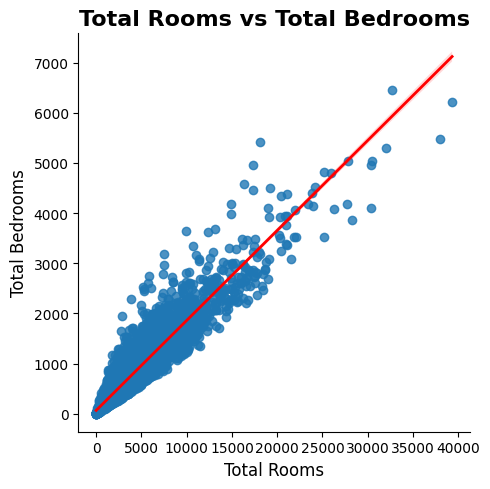

In [30]:
# Scatter plot with linear regression
sns.lmplot(
    x="total_rooms",
    y="total_bedrooms",
    data=data,
    line_kws={"color": "red", "lw": 2},  # Set line color and width
)

# Add titles and labels
plt.title("Total Rooms vs Total Bedrooms", fontsize=16, fontweight="bold")
plt.xlabel("Total Rooms", fontsize=12)
plt.ylabel("Total Bedrooms", fontsize=12)

plt.tight_layout()
plt.show()

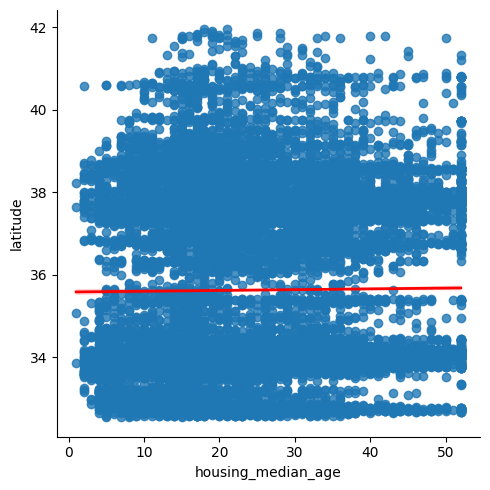

In [31]:
sns.lmplot(
    data=data,
    x="housing_median_age",
    y="latitude",
    line_kws={"color": "red", "lw": 2},  # Set line color and width
)

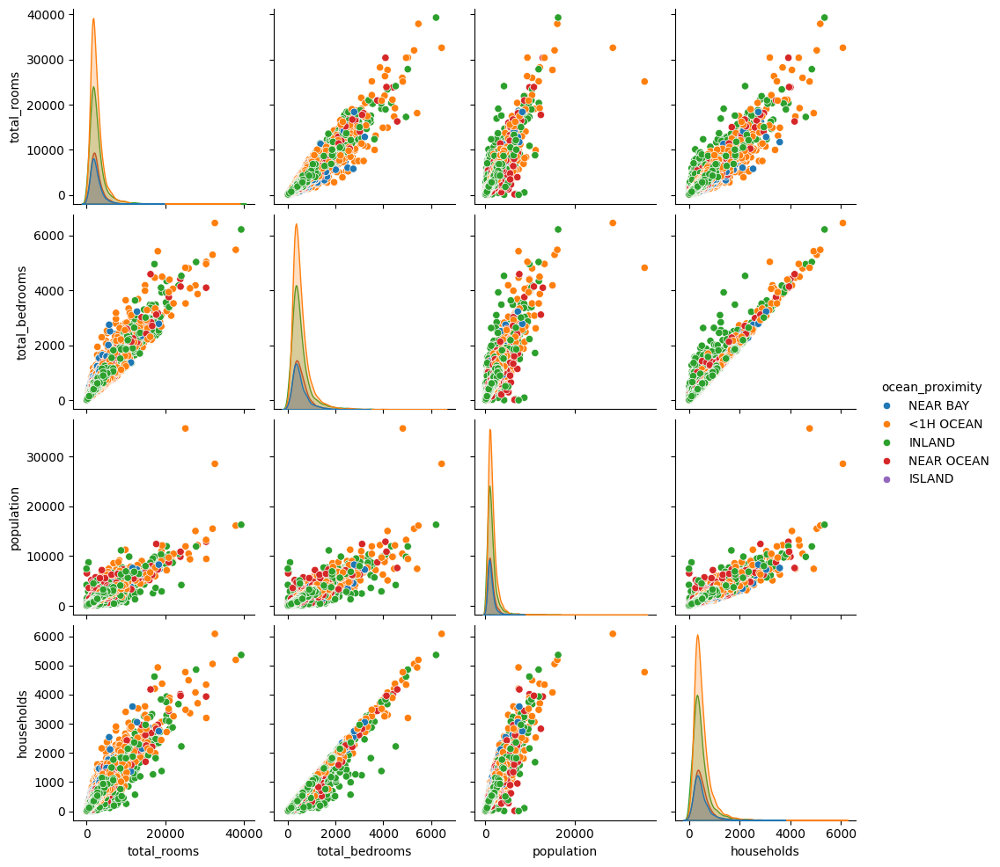

In [32]:
# Plot pairwise relationships in a dataset.
sns.pairplot(
    data=data[
        [
            "total_rooms",
            "total_bedrooms",
            "population",
            "households",
            "ocean_proximity",
        ]
    ],
    hue="ocean_proximity",
)

## Data Preprocessing

In [33]:
# Missing Values per Column
data.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [34]:
data.loc[data.total_bedrooms.isna()].ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     102
INLAND         55
NEAR OCEAN     30
NEAR BAY       20
Name: count, dtype: int64

In [35]:
data.total_bedrooms.mean().round()

np.float64(538.0)

In [37]:
data.loc[data.total_bedrooms.isna(), "total_bedrooms"]

290     NaN
341     NaN
538     NaN
563     NaN
696     NaN
         ..
20267   NaN
20268   NaN
20372   NaN
20460   NaN
20484   NaN
Name: total_bedrooms, Length: 207, dtype: float64

In [38]:
# Fill NaN values  --  USE the AVERAGE per "class" (e.g. ocean_proximity)
total_bedrooms_op = (
    data.groupby("ocean_proximity")
    .apply(lambda l: l.total_bedrooms.mean(), include_groups=False)
    .astype(int)
)
print(total_bedrooms_op)

ocean_proximity
<1H OCEAN     546
INLAND        533
ISLAND        420
NEAR BAY      514
NEAR OCEAN    538
dtype: int64


In [39]:
data.loc[:, "total_bedrooms_mean"] = data.groupby(
    "ocean_proximity", group_keys=False
).apply(lambda l: l.total_bedrooms.fillna(total_bedrooms_op[l.name]))

/var/folders/5_/7z8lzq913cl3q8m0z5pnmpjr0000gn/T/ipykernel_7755/3545199679.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(lambda l: l.total_bedrooms.fillna(total_bedrooms_op[l.name]))


AVERAGE / MEDIAN per 'ocean_proximity' can be deceiving (Why ?) \
Let's use the houses' price instead.
> **__NOTE__**: it's a numeric feature --> DISCRETIZATION


In [40]:
data.loc[:, "median_house_value_range"] = pd.cut(data.median_house_value, bins=15)
data.median_house_value_range.value_counts(sort=False)

median_house_value_range
(14513.998, 47332.467]       127
(47332.467, 79665.933]      1764
(79665.933, 111999.4]       2598
(111999.4, 144332.867]      2666
(144332.867, 176666.333]    2934
(176666.333, 208999.8]      2270
(208999.8, 241333.267]      2047
(241333.267, 273666.733]    1482
(273666.733, 306000.2]      1039
(306000.2, 338333.667]       785
(338333.667, 370667.133]     765
(370667.133, 403000.6]       441
(403000.6, 435334.067]       318
(435334.067, 467667.533]     259
(467667.533, 500001.0]      1145
Name: count, dtype: int64

In [41]:
# Fill NaN values  --  USE the MEDIAN per "houses' price range"
total_bedrooms_op = (
    data.groupby(
        "median_house_value_range",
        observed=False,
    )
    .apply(
        lambda l: l.total_bedrooms.median(),
        include_groups=False,
    )
    .astype(int)
)

data.loc[:, "total_bedrooms_median_range"] = data.groupby(
    "median_house_value_range",
    group_keys=False,
    observed=False,
).apply(
    lambda l: l.total_bedrooms.fillna(total_bedrooms_op[l.name]),
    include_groups=False,
)

In [42]:
data.loc[data.total_bedrooms.isna()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,total_bedrooms_mean,median_house_value_range,total_bedrooms_median_range
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY,514.0,"(144332.867, 176666.333]",430.0
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY,514.0,"(79665.933, 111999.4]",406.0
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY,514.0,"(144332.867, 176666.333]",430.0
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY,514.0,"(241333.267, 273666.733]",474.0
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY,514.0,"(176666.333, 208999.8]",447.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20267,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN,538.0,"(208999.8, 241333.267]",463.0
20268,-119.18,34.19,19.0,2393.0,NaN,1938.0,762.0,1.6953,167400.0,NEAR OCEAN,538.0,"(144332.867, 176666.333]",430.0
20372,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN,546.0,"(403000.6, 435334.067]",472.0
20460,-118.75,34.29,17.0,5512.0,NaN,2734.0,814.0,6.6073,258100.0,<1H OCEAN,546.0,"(241333.267, 273666.733]",474.0


In [43]:
# ALTERNATIVE - Infer it using another correlated feature (e.g. households, total_rooms)
# This approach is sensitive to outliers; Use it wisely...
from sklearn.linear_model import LinearRegression

# input, target = 'households', 'total_bedrooms'
input, target = "total_rooms", "total_bedrooms"

lr = LinearRegression()

# Find samples with non-missing values
mask = ~data[target].isna()

# # Train the model on known values
X = data.loc[mask, input].to_numpy().reshape(-1, 1)
y = data.loc[mask, target].to_numpy().reshape(-1, 1)
lr.fit(X, y)

# Fill in the Missing values
pred = lr.predict(data.loc[~mask, input].to_numpy().reshape(-1, 1)).astype(int)
data.loc[~mask, "total_bedrooms_lr"] = pred

In [45]:
data.loc[data.total_bedrooms_lr.isna()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,total_bedrooms_mean,median_house_value_range,total_bedrooms_median_range,total_bedrooms_lr
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,129.0,"(435334.067, 467667.533]",129.0,NaN
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,1106.0,"(338333.667, 370667.133]",1106.0,NaN
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,190.0,"(338333.667, 370667.133]",190.0,NaN
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,235.0,"(338333.667, 370667.133]",235.0,NaN
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,280.0,"(338333.667, 370667.133]",280.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,374.0,"(47332.467, 79665.933]",374.0,NaN
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,150.0,"(47332.467, 79665.933]",150.0,NaN
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,485.0,"(79665.933, 111999.4]",485.0,NaN
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,409.0,"(79665.933, 111999.4]",409.0,NaN


Further Reading: [Dealing With Missing Values in Python – A Complete Guide](https://www.analyticsvidhya.com/blog/2021/05/dealing-with-missing-values-in-python-a-complete-guide/)

### Data Smoothing / Removing Outliers

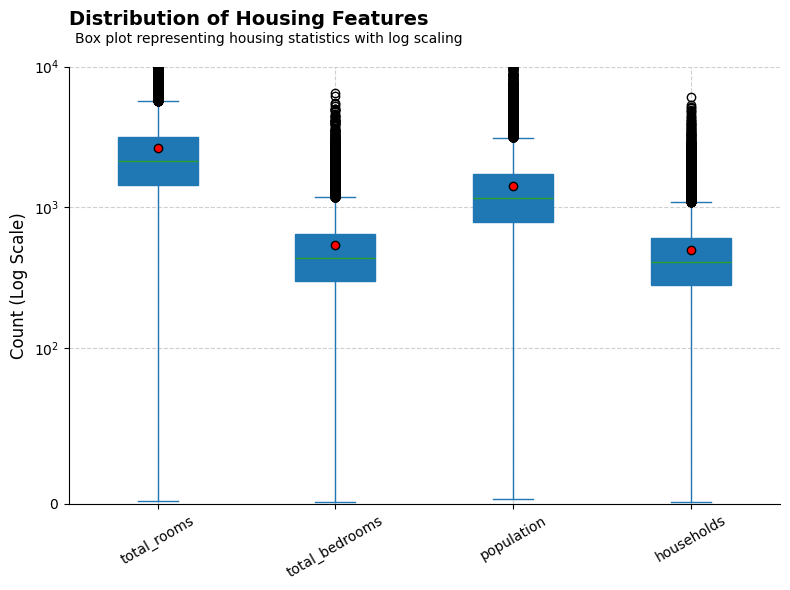

In [46]:
fig, ax = plt.subplots(figsize=(8, 6))

# Box plot
data[["total_rooms", "total_bedrooms", "population", "households"]].plot.box(
    ax=ax,
    rot=30,  # Rotate labels for readability
    showmeans=True,  # Show mean indicator
    meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "black"},
    patch_artist=True,  # Fill boxes with color
)

# Apply log scale while keeping zero values visible
ax.set_yscale("symlog", linthresh=100)

# Grid & Layout
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_ylim(0, 10000)

# Labels and Title
ax.set_ylabel("Count (Log Scale)", fontsize=12)
ax.set_title(
    "Distribution of Housing Features",
    fontsize=14,
    fontweight="bold",
    loc="left",
    pad=30,
)
plt.figtext(
    0.1,
    0.92,
    "Box plot representing housing statistics with log scaling",
    ha="left",
    fontsize=10,
)

# Seaborn Style
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
data.groupby(["ocean_proximity"]).plot.box(rot=45)

In [ ]:
data.info()

In [ ]:
# Select only numerical columns
num_cols = [
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
]

# Melt DataFrame to convert wide format into long format
melted_data = data.melt(
    id_vars=["ocean_proximity"],
    value_vars=num_cols,
    var_name="Feature",
    value_name="Value",
)

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Box plot with seaborn
sns.boxplot(
    data=melted_data,
    x="Feature",
    y="Value",
    hue="ocean_proximity",  # Group by ocean_proximity
    palette="pastel",
    showfliers=False,  # Hide outliers for a cleaner look
    linewidth=1.2,
)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha="right")

# Labels and title
ax.set_xlabel("Feature", fontsize=12)
ax.set_ylabel("Value", fontsize=12)
ax.set_title("Feature Distributions by Ocean Proximity", fontsize=14, fontweight="bold")

# Move the legend outside the plot
plt.legend(title="Ocean Proximity", bbox_to_anchor=(1.05, 1), loc="upper left")

sns.despine()
plt.tight_layout()
plt.show()

### Outlier Detection (IQR Method - https://online.stat.psu.edu/stat200/lesson/3/3.2 - __IQR = Q75 - Q25__)
  * #### x > Q75 + 1.5 * IQR  
  * #### x < Q25 - 1.5 * IQR

In [47]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,total_bedrooms_mean,total_bedrooms_median_range,total_bedrooms_lr
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,207.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,537.874806,536.876357,524.115942
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,419.267716,419.393845,320.626126
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,1.000000,1.000000,92.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,297.000000,297.000000,299.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,438.000000,435.000000,451.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,643.250000,643.250000,686.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,6445.000000,6445.000000,2165.000000


In [48]:
def find_outliers_IQR(df, feats, strict=False):
    q1, q3 = df[feats].quantile(0.25), df[feats].quantile(0.75)
    IQR = q3 - q1

    return df.loc[
        (
            np.logical_and.reduce(df[feats] <= (q1 - 1.5 * IQR), axis=1)
            if strict
            else np.logical_or.reduce(df[feats] <= (q1 - 1.5 * IQR), axis=1)
        )
        | (
            np.logical_and.reduce(df[feats] >= (q3 + 1.5 * IQR), axis=1)
            if strict
            else np.logical_or.reduce(df[feats] >= (q3 + 1.5 * IQR), axis=1)
        )
    ]

In [49]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,total_bedrooms_mean,median_house_value_range,total_bedrooms_median_range,total_bedrooms_lr
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,129.0,"(435334.067, 467667.533]",129.0,NaN
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,1106.0,"(338333.667, 370667.133]",1106.0,NaN
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,190.0,"(338333.667, 370667.133]",190.0,NaN
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,235.0,"(338333.667, 370667.133]",235.0,NaN
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,280.0,"(338333.667, 370667.133]",280.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,374.0,"(47332.467, 79665.933]",374.0,NaN
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,150.0,"(47332.467, 79665.933]",150.0,NaN
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,485.0,"(79665.933, 111999.4]",485.0,NaN
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,409.0,"(79665.933, 111999.4]",409.0,NaN


In [50]:
data.drop(
    find_outliers_IQR(
        data.copy(), feats=["total_rooms", "total_bedrooms", "population", "households"]
    ).index
)
# .astype({'median_house_value_range':str}).drop(['total_bedrooms_lr'], axis=1).to_csv('../data/housing_clean.csv', index=False, header=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,total_bedrooms_mean,median_house_value_range,total_bedrooms_median_range,total_bedrooms_lr
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,129.0,"(435334.067, 467667.533]",129.0,NaN
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,190.0,"(338333.667, 370667.133]",190.0,NaN
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,235.0,"(338333.667, 370667.133]",235.0,NaN
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,280.0,"(338333.667, 370667.133]",280.0,NaN
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY,213.0,"(241333.267, 273666.733]",213.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,374.0,"(47332.467, 79665.933]",374.0,NaN
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,150.0,"(47332.467, 79665.933]",150.0,NaN
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,485.0,"(79665.933, 111999.4]",485.0,NaN
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,409.0,"(79665.933, 111999.4]",409.0,NaN


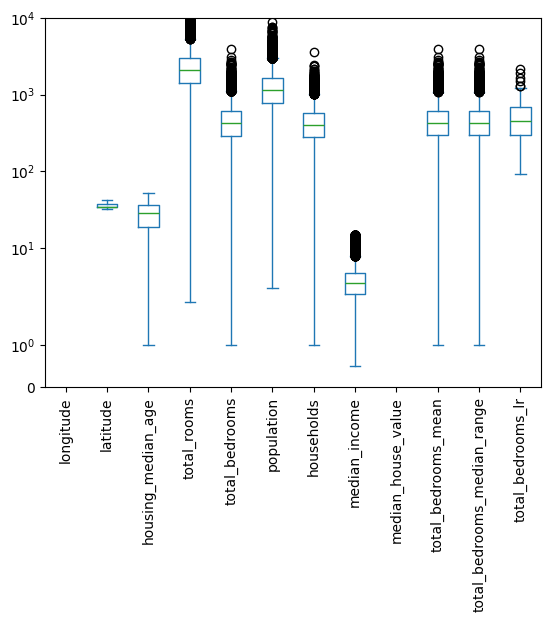

In [51]:
ax = data.drop(
    find_outliers_IQR(
        data.copy(),
        feats=[
            "total_rooms",
            "total_bedrooms",
            "population",
            "households",
        ],
        strict=True,
    ).index
).plot.box(rot=90)

ax.set_ylim(0, 10000)
ax.set_yscale("symlog")

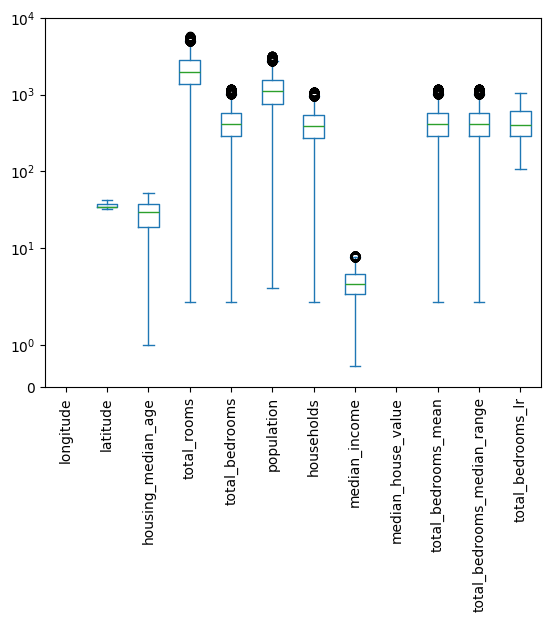

In [52]:
ax = data.drop(
    find_outliers_IQR(
        data.copy(),
        feats=[
            "total_rooms",
            "total_bedrooms",
            "population",
            "households",
            "median_income",
        ],
        strict=False,
    ).index
).plot.box(rot=90)

ax.set_ylim(0, 10000)
ax.set_yscale("symlog")

In [53]:
feat = "total_bedrooms"

q25, q75 = data.describe()[feat][["25%", "75%"]]
iqr = q75 - q25

In [ ]:
~data.total_bedrooms.between(q25 - 1.5 * iqr, q75 + 1.5 * iqr, inclusive="neither")

In [54]:
outliers = data.loc[
    ~data.total_bedrooms.between(q25 - 1.5 * iqr, q75 + 1.5 * iqr, inclusive="both")
].copy()
outliers

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,total_bedrooms_mean,median_house_value_range,total_bedrooms_median_range,total_bedrooms_lr
95,-122.26,37.80,36.0,5329.0,2477.0,3469.0,2323.0,2.0096,130000.0,NEAR BAY,2477.0,"(111999.4, 144332.867]",2477.0,NaN
96,-122.26,37.82,31.0,4596.0,1331.0,2048.0,1180.0,2.8345,183800.0,NEAR BAY,1331.0,"(176666.333, 208999.8]",1331.0,NaN
98,-122.26,37.82,22.0,3682.0,1270.0,2024.0,1250.0,1.2185,170000.0,NEAR BAY,1270.0,"(144332.867, 176666.333]",1270.0,NaN
100,-122.25,37.81,29.0,4656.0,1414.0,2304.0,1250.0,2.4912,257800.0,NEAR BAY,1414.0,"(241333.267, 273666.733]",1414.0,NaN
101,-122.25,37.81,28.0,5806.0,1603.0,2563.0,1497.0,3.2177,273400.0,NEAR BAY,1603.0,"(241333.267, 273666.733]",1603.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20539,-121.71,38.56,20.0,8627.0,1516.0,4071.0,1466.0,4.2198,164100.0,INLAND,1516.0,"(144332.867, 176666.333]",1516.0,NaN
20543,-121.74,38.55,33.0,6861.0,1820.0,3717.0,1767.0,1.7311,182600.0,INLAND,1820.0,"(176666.333, 208999.8]",1820.0,NaN
20544,-121.76,38.55,23.0,8800.0,1857.0,6330.0,1832.0,2.0650,219400.0,INLAND,1857.0,"(208999.8, 241333.267]",1857.0,NaN
20563,-121.75,38.67,9.0,12139.0,2640.0,6837.0,2358.0,3.1250,132500.0,INLAND,2640.0,"(111999.4, 144332.867]",2640.0,NaN


In [ ]:
# Smoothing ```total_bedrooms``` feature using Regression based on ```total_rooms```
from sklearn.linear_model import LinearRegression

normal = data.drop(outliers.index, axis=0).copy()
input, target = "total_rooms", "total_bedrooms"

lr = LinearRegression()

# Train the model on non-outlier values
X = normal.loc[:, input].values.reshape(-1, 1)
y = normal.loc[:, target].values.reshape(-1, 1)
lr.fit(X, y)

# Fill in the Missing values
pred = lr.predict(data.loc[outliers.index, input].to_numpy().reshape(-1, 1)).astype(int)
data.loc[outliers.index, f"{target}_smooth"] = pred

In [ ]:
data.loc[
    ~data[f"{feat}_smooth"].between(q25 - 1.5 * iqr, q75 + 1.5 * iqr, inclusive="both")
].copy()

In [ ]:
### ALTERNATIVE: Discover and Drop Outliers using Clustering (e.g. DBSCAN)